##### Name : Febriani Patricia
##### Student Number: 48914127

# DATA2001 Assignment 2 (Weight: 25%)


The aim of this assignment is to gain practical experience in analysing unstructured data.
You should only submit your completed Jupyter notebook in .ipynb format via Blackboard, including written answers in markdown and results from executed code cells.


The assignment comprises 5 main tasks: Data Exploration, Data Preprocessing, Model Training, Model Evaluation, and Model Analysis. You will address and compare two tasks: sentiment analysis and rating prediction.


The dataset you will work with in this assignment comprises text reviews about various android applications and their corresponding ratings. Further information about the dataset can be found [here](https://huggingface.co/datasets/sealuzh/app_reviews).


## Task 1: Data Exploration





1. Load the dataset from the file "app_review.csv". How many records does the dataset contain? How many distinct classes are there in the dataset? Randomly select and print 5 reviews with a rating of '1' and 5 reviews with a rating of '5'.

In [191]:
import pandas as pd
import warnings
import numpy as np
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

In [192]:
# load the data
reviews = pd.read_csv(filepath_or_buffer='app_review.csv')
reviews

,Review,Rating
0,Thanks a lot I feel very good when i have down...,1
1,Its worst,1
2,Used too much space,1
3,Doesn't work a bit on my moto g,1
4,Hate it This does not work,1
...,...,...
57608,Excellent art The name of the work should also...,5
57609,The app team needs sincere appreciation for ma...,5
57610,Works great. I had to calibrate the phone's co...,5
57611,Thanks for making this!,5


In [194]:
# Number of records in the dataset
num_records = reviews.shape[0]
print(f"Number of records: {num_records}")

# Number of distinct classes
distinct_classes = reviews['Rating'].nunique()
print(f"Number of distinct rating classes: {distinct_classes}")

# 5 reviews with rating '1'
reviews_1 = reviews[reviews['Rating'] == 1].sample(5, random_state=1)
print("\n5 Random Reviews with Rating 1:")
print(reviews_1[['Review', 'Rating']])

# 5 reviews with rating '5'
reviews_5 = reviews[reviews['Rating'] == 5].sample(5, random_state=1)
print("\n5 Random Reviews with Rating 5:")
print(reviews_5[['Review', 'Rating']])

Number of records: 57613
Number of distinct rating classes: 5

5 Random Reviews with Rating 1:
                                                 Review  Rating
4739  App closing automatically Am using one +2........       1
5605  Too easy to replace malware version and unable...       1
5495                                        google mc h       1
4205                                               Ajay       1
3228                                           Bb K J J       1

5 Random Reviews with Rating 5:
                                                  Review  Rating
23570                             Fantastic and accurate       5
29298  Best app for sending messages and pics Its fas...       5
44030                                         Great Good       5
30767  Not working Galaxy S5 From what I've read this...       5
38111                                      Very usedfoll       5


2. Is the class distribution balanced? To support your answer, create a bar plot with the classes on the x-axis and the number of reviews in each class on the y-axis. Additionally, based on your observations of the reviews and the class distribution, determine whether there are more positive or negative reviews.

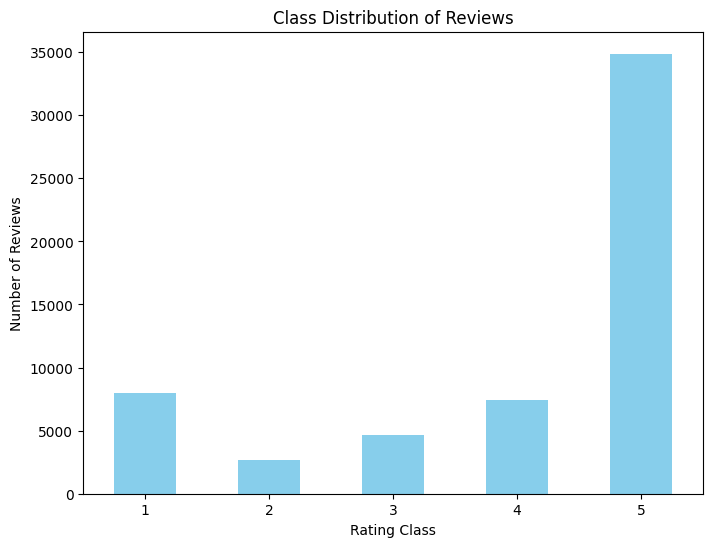

Number of positive reviews (4 & 5): 42324
Number of negative reviews (1 & 2): 10650
There are more positive reviews.


In [195]:
# Count the distribution of each class (Rating)
distribution = reviews['Rating'].value_counts().sort_index()

# Plotting the class distribution
plt.figure(figsize=(8, 6))
distribution.plot(kind='bar', color='skyblue')
plt.title('Class Distribution of Reviews')
plt.xlabel('Rating Class')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.show()

# Determine the proportion of positive and negative reviews
positive_reviews = distribution[4] + distribution[5]
negative_reviews = distribution[1] + distribution[2]

print(f"Number of positive reviews (4 & 5): {positive_reviews}")
print(f"Number of negative reviews (1 & 2): {negative_reviews}")

# Conclusion on the class distribution balance
if positive_reviews > negative_reviews:
    print("There are more positive reviews.")
else:
    print("There are more negative reviews.")

**Analysis:**

From the plot, it is evident that the distribution is imbalanced, with significantly more reviews having a rating of 5 compared to other ratings. Typically, ratings 4 and 5 are considered positive reviews, ratings 1 and 2 are viewed as negative, and rating 3 is seen as neutral. As shown in the plot, there are 42,324 reviews with ratings 4 and 5 combined, while ratings 1 and 2 account for a total of 10,650 reviews. This suggests that the dataset contains a greater number of positive reviews.

## Task 2: Data Preprocessing

- Use the provided "clean_data" function to remove unnecessary symbols and clean the dataset.



In [196]:
import re

def clean_data(text):

    # Format words and remove unwanted characters
    text = re.sub(r'https?:\/\/.*[\r\n]*', '', text, flags=re.MULTILINE)
    text = re.sub(r'\<a href', ' ', text)
    text = re.sub(r'&amp;', '', text)
    text = re.sub(r'[_"\-;%()|+&=*%.,!?:#$@\[\]/]', ' ', text)
    text = re.sub(r'<br />', ' ', text)
    text = re.sub(r'br', ' ', text)
    text = re.sub(r'\'', ' ', text)

    return text

In [197]:
# Print the review before applying the clean_data function
print("Before:\n", reviews.loc[19, "Review"])

# Replace NaN or non-string values in the 'Review' column with an empty string
reviews['Review'] = reviews['Review'].fillna('')

# Ensure all entries in the 'Review' column are strings
reviews['Review'] = reviews['Review'].astype(str)

# Apply the provided clean_data function
reviews['Review'] = reviews['Review'].apply(clean_data)

# Print the review after applying the clean_data function 
print("\nAfter the function is applied:\n", reviews.loc[19, "Review"])

# Adding a new format words to remove some excessive spaces
reviews['Review'] = reviews['Review'].apply(lambda text: re.sub(r'\s+', ' ', text))

# Print the neater words version 
print("\nA neater version:\n", reviews.loc[19, "Review"])

Before:
 Broken with last update! I used to love this app  but the latest update has removed the """"""""""""""""save"""""""""""""""" button from the """"""""""""""""edit image"""""""""""""""" screen  meaning I can no longer add captions or image metadata. A horrible oversight by the WordPress team!""

After the function is applied:
 Broken with last update  I used to love this app  but the latest update has removed the                 save                 button from the                 edit image                 screen  meaning I can no longer add captions or image metadata  A horrible oversight by the WordPress team   

A neater version:
 Broken with last update I used to love this app but the latest update has removed the save button from the edit image screen meaning I can no longer add captions or image metadata A horrible oversight by the WordPress team 


- Split the clean dataset into separate train and test sets. For this, use the "Review" field as the feature vector (X) and the "Rating" field as the label vector (Y).

In [198]:
from sklearn.model_selection import train_test_split

In [199]:
# Define X (features) and y (target)
X = reviews["Review"]
y = reviews["Rating"]

# Split the data into train-test sets where 30% of data is used as the test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=True, random_state=0)


- Transform the cleaned data into a numerical representation using Bag of Words (BoW) and remove any stop words. Save the BoW representation in the variables train_data_BOW and test_data_BOW.

In [200]:
from sklearn.feature_extraction.text import CountVectorizer

from nltk.corpus import stopwords
import nltk


nltk.download('stopwords')
nltk.download('omw-1.4')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/s4891412/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/s4891412/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package wordnet to /home/s4891412/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [201]:
# Displaying the most common words on the reviews
vectorizer = CountVectorizer()
X_train_BOW = vectorizer.fit_transform(X_train)

# Get the frequency of each words
words_frequencies = X_train_BOW.sum(axis=0).A1
words = vectorizer.get_feature_names_out()

# Create a DataFrame to visualize most common terms
df = pd.DataFrame({'words': words, 'frequency': words_frequencies})
df = df.sort_values(by='frequency', ascending=False)
print(df.head(40))


        words  frequency
10338      it      16582
19951     the      14305
20217      to      12832
1688      app      11065
1479      and       9433
20016    this       7368
10293      is       7045
8408     good       6296
7629      for       5658
13266      my       4923
14080      of       4534
3496      but       4332
8612    great       3992
14201      on       3868
22457     you       3716
21353    very       3612
13836     not       3504
9849       in       3498
19944    that       2961
11921    love       2941
3618      can       2937
13620    nice       2784
9039     have       2742
2802     best       2690
22038    with       2537
11664    like       2466
18507      so       2399
21083     use       2274
2643       be       2121
1278      all       2070
22128    work       2009
13762      no       1979
12453      me       1937
21010  update       1836
10752    just       1769
10363     its       1693
21896    when       1632
15050   phone       1594
22145   works       1590


**Defining Stopwords**

From the data above, we can see there are lots of words that don’t really help in understanding the review. I chose the words "app," "update," "use," and "work" as custom stopwords because they appear a lot in the reviews but don't really help in understanding whether the review is positive or negative. For example, "app" and "update" are related to the product, but they don’t give much insight into how the reviewer feels. Similarly, "use" and "work" are too general and can be found in both good and bad reviews. By removing these words, the model can focus more on the important words that actually show the sentiment of the review.

In [202]:
# Define stop words
stop_words = stopwords.words('english')
stop_words.extend(['app', 'apps', 'update', 'use', 'works'])

# Initialize CountVectorizer with stopwords removal and min_df to filter rare words
vectorizer = CountVectorizer(stop_words=stop_words, min_df=0.01)

# Fit the vectorizer object to the training data (X_train)
vectorizer.fit(X_train)

# Transform both train and test data into BoW representation
train_data_BOW = vectorizer.transform(X_train)
test_data_BOW = vectorizer.transform(X_test)

# visualize BOW for the training data
training_data_BOW = pd.DataFrame(data=train_data_BOW.toarray(), columns=vectorizer.get_feature_names_out())
print(training_data_BOW.head(15))

# visualize the test data BoW 
testing_data_BOW = pd.DataFrame(data=test_data_BOW.toarray(), columns=vectorizer.get_feature_names_out())
print(testing_data_BOW.head(15))

    add  also  always  amazing  android  awesome  back  bad  best  better  \
0     0     0       1        0        0        0     0    0     0       0   
1     0     0       0        0        0        0     0    0     0       0   
2     0     0       0        0        0        0     0    0     0       0   
3     0     0       0        0        0        0     0    0     0       0   
4     0     0       0        0        0        0     0    0     0       0   
5     0     0       0        0        0        0     0    0     0       1   
6     0     0       0        0        0        0     0    0     0       0   
7     0     0       0        0        0        0     1    0     0       0   
8     0     0       0        0        0        0     0    0     0       0   
9     0     0       0        0        0        0     0    0     0       0   
10    1     0       0        0        0        0     1    0     0       0   
11    0     0       0        0        0        0     0    0     0       0   

The numbers in the table indicate how many times a particular word appears in each review. if a word occurs once in a review, its corresponding cell will show '1 or more', and if it doesn’t appear, it will show '0'. This numerical representation allows us to analyze and compare text data by treating the presence or frequency of words as features in the dataset. For example, in the first matrix, the word "always" appears once in review 0 (as indicated by the value 1 in that row-column pair), while "amazing" does not appear in review 3, as indicated by the value 0 in that location. Similarly, the word "best" appears in review 0, but not in review 1.

## Task 3: Model Training

Define 2 Logistic Regression models: *model1* and *model2* and train the models as follows:
- Train the first Logistic Regression model to predict the application rating (Y).


In [203]:
model1 = LogisticRegression(random_state=random_state)
model1.fit(train_data_BOW, y_train)

LogisticRegression(random_state=RandomState(MT19937) at 0x7FFF60F92240)

- Create an additional binary label by assigning ‘1’ – positive for the product ratings 4 and 5; and "–1" for product ratings 1, 2 and 3. Store it in y_train_binary and y_test_binary.

*Tip: you can use a function copy.deepcopy for creating a copy of label variables*

In [204]:
import copy

In [205]:
y_binary = copy.deepcopy(reviews['Rating'])
y_binary = y_binary.apply(lambda x: 1 if x in [4, 5] else -1)

# Split the binary labels
y_train_binary = y_binary.loc[y_train.index]
y_test_binary = y_binary.loc[y_test.index]


- Train the second Logistic Regression model to predict the binary sentiment label (Y_binary).


In [206]:
model2 = LogisticRegression(random_state=random_state)
model2.fit(train_data_BOW, y_train_binary)

LogisticRegression(random_state=RandomState(MT19937) at 0x7FFF60F92240)


- Make and store predictions for both models

In [207]:
# Predictions for both models
predict1 = model1.predict(test_data_BOW)
predict2 = model2.predict(test_data_BOW)

print ("model 1 prediction:\n", predict1)
print ("model 2 prediction:\n", predict2)

model 1 prediction:
 [5 5 5 ... 5 1 5]
model 2 prediction:
 [ 1  1  1 ...  1 -1  1]



## Task 4: Model Evaluation

- Compute and compare the test accuracy of Model 1 and Model 2. Based on your results, analyze which task is easier: binary sentiment prediction or multi-class rating prediction.

In [208]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Calculate accuracy for Model 1 (multi-class rating prediction)
accuracy_model1 = accuracy_score(y_test, predict1)
print(f"Test Accuracy of Model 1 (multi-class rating prediction): {accuracy_model1:.4f}")

# Calculate accuracy for Model 2 (binary sentiment prediction)
accuracy_model2 = accuracy_score(y_test_binary, predict2)
print(f"Test Accuracy of Model 2 (binary sentiment prediction): {accuracy_model2:.4f}")


Test Accuracy of Model 1 (multi-class rating prediction): 0.6371
Test Accuracy of Model 2 (binary sentiment prediction): 0.7855


**Analyze:**

Based on the accuracy comparison, binary sentiment prediction is generally easier than multi-class rating prediction. This is because binary sentiment prediction only involves distinguishing between two broad categories: positive (ratings 4 and 5) and negative (ratings 1, 2, and 3). In contrast, multi-class rating prediction requires the model to predict one of five distinct classes, which introduces more complexity as it must capture the subtle differences between ratings (e.g., distinguishing a 3-star review from a 4-star review). As a result, binary sentiment classification tends to yield higher accuracy, while multi-class tasks are more prone to misclassification due to the finer distinctions involved.



- For Model 1,  compute additional evaluaton measures, namely confusion matrix, precision and recall.  

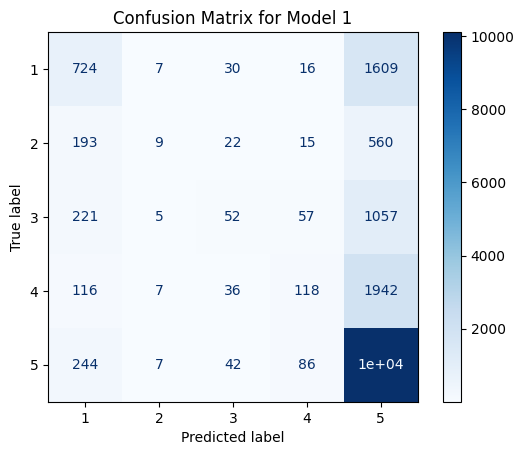

Classification Report for Model 1:
              precision    recall  f1-score   support

           1       0.48      0.30      0.37      2386
           2       0.26      0.01      0.02       799
           3       0.29      0.04      0.07      1392
           4       0.40      0.05      0.09      2219
           5       0.66      0.96      0.78     10488

    accuracy                           0.64     17284
   macro avg       0.42      0.27      0.27     17284
weighted avg       0.56      0.64      0.55     17284



In [189]:
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Compute the confusion matrix
cm = confusion_matrix(y_test, predict1)

# Display the confusion matrix with labels 1 to 5
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1, 2, 3, 4, 5])
display.plot(cmap='Blues')
plt.title("Confusion Matrix for Model 1")
plt.show()

# Calculate precision, recall, and F1-score
class_report_model1 = classification_report(y_test, predict1)
print("Classification Report for Model 1:")
print(class_report_model1)


- Based on the confusion matrix obtained in the previous question (referring to Model 1, the Logistic Regression for rating prediction), identify and state the number of samples that were classified to have the rating of 1 (the lowest rating), but in reality, they had an actual rating of 5 (the highest rating).

**Analysis:**

From the confusion matrix, we can see that 244 samples were incorrectly predicted to have a rating of 1 (the lowest rating) when they actually had a rating of 5 (the highest rating). This figure is found in the row marked "True Label = 5" and the column labeled "Predicted Label = 1." This indicates that 244 reviews that should have been classified as a rating of 5 were misclassified as having a rating of 1.

## Task 5: Model Analysis



- Discuss the importance of considering alternative evaluation measures, such as precision and recall, instead of relying solely on accuracy. Based on this discussion, identify the most suitable evaluation metric for Model 1.

**The Need for Alternative Evaluation Metrics:**

Accuracy is a commonly used metric but can be misleading when evaluating models trained on imbalanced datasets. In cases where one class dominates, a model may achieve high accuracy simply by predicting the majority class most of the time, even if it struggles with minority classes. In such situations, metrics like precision and recall are critical for gaining a deeper insight into the model's performance. For example, precision measures the proportion of correct predictions for a particular class, which is particularly important when false positives carry significant consequences. For Model 1, the low precision for certain ratings suggests that many reviews are incorrectly classified as those ratings.

**Accuracy's Shortcomings:**

Although Model 1 achieves an overall accuracy of 64%, this figure doesn't tell the whole story. The confusion matrix and classification report show that the model has a very high recall for class 5 (96%) but performs poorly for lower ratings, such as class 2 (1%) and class 3 (4%). This reveals that the model is effective at identifying high ratings but fails to capture lower ratings accurately, which are crucial for identifying negative reviews. Therefore, relying solely on accuracy masks the model’s weaknesses, especially when handling imbalanced data where performance on minority classes matters just as much.

**The most suitable evaluation metric for Model 1:**

Given the multi-class nature of the task and the imbalanced dataset, accuracy is not the most appropriate evaluation metric for Model 1. Metrics like macro-averaged F1-score or weighted F1-score offer a better assessment since they consider both precision and recall across all classes. The macro F1-score, which averages performance across all classes, is particularly useful when the goal is to give equal weight to both frequent and infrequent ratings. By focusing on the F1-score, we can get a clearer understanding of the model's ability to handle underrepresented ratings, which is vital in applications like sentiment analysis or detecting critical feedback.


- For binary sentiment prediction (Model 2), visualize important words with their model coefficients.  

*Tip: you can reuse the function plot_coefficients from prac. session.*

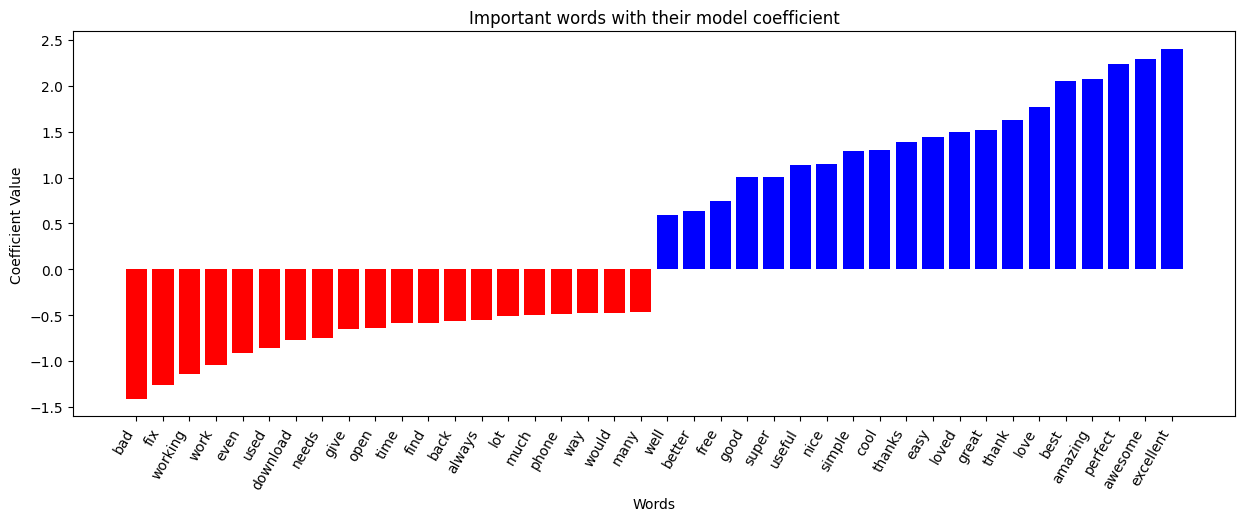

In [213]:
import numpy as np
import matplotlib.pyplot as plt

# Function to plot the top N positive and negative coefficients
def plot_coefficients(classifier, feature_names, top_features=20):
    # Get the coefficients from the classifier and sort them
    coef = classifier.coef_.ravel()
    top_positive_coefficients = np.argsort(coef)[-top_features:]
    top_negative_coefficients = np.argsort(coef)[:top_features]
    
    # Combine the top positive and negative coefficients for visualization
    top_coefficients = np.hstack([top_negative_coefficients, top_positive_coefficients])
    
    # Plot the coefficients as a bar chart
    plt.figure(figsize=(15, 5))
    colors = ['red' if c < 0 else 'blue' for c in coef[top_coefficients]]
    plt.bar(np.arange(2 * top_features), coef[top_coefficients], color=colors)
    feature_names = np.array(feature_names)
    plt.xticks(np.arange(2 * top_features), feature_names[top_coefficients], rotation=60, ha='right')
    plt.title("Important words with their model coefficient")
    plt.xlabel("Words")
    plt.ylabel("Coefficient Value")
    plt.show()

feature_names = vectorizer.get_feature_names_out()
plot_coefficients(model2, feature_names)


- Analyze the quality of the features produced by Model 2 by examining the words with the highest coefficients for both the positive and negative classes.  Identify any potential bias in the model, and explain how this bias could affect its performance.

**Analysis:**

The analysis of Model 2 for binary sentiment prediction shows that the model does a good job of picking up on clear sentiment words. On the positive side, words like “excellent,” “awesome,” and “perfect” have the highest coefficients, which clearly indicate very positive feedback. On the negative side, words like “bad,” “fix,” and “working” stand out. These terms usually appear in reviews that are either really positive or really negative, which suggests the model performs well when the sentiment is straightforward and easy to identify.

However, some of the words on the negative side, such as “working,” “time,” and “needs,” could be a bias. These words can appear in different contexts, not always indicating negativity. For instance, the word “working” could be part of a complaint like “it's not working well,” or in a positive statement such as “working perfectly.” This makes it harder for the model to correctly predict the sentiment in certain cases, suggesting that it may sometimes label mixed reviews as negative due to the ambiguity of these words.

Additionally, the model seems to focus on words that are specific to digital products, like “free,” “download,” and “work.” While this is useful for reviews related to software or apps, it might not work as well for reviews about physical products or services. Words like “quality” or “service” might be more relevant in those cases. This shows that the model could struggle to generalize well across different types of reviews if it’s mainly trained on one specific area.

In conclusion, while the model does a good job of detecting very clear positive or negative sentiments, it might have trouble with more neutral or mixed reviews due to the bias in its word choices. It also may not perform as well in different review contexts if it relies heavily on words specific to one type of product.